# Этап 1: ETL Pipeline — PostgreSQL → MinIO
Этот ноутбук реализует полный цикл извлечения, преобразования и загрузки данных:
- Подключение к PostgreSQL
- Чтение таблиц (wells, production, telemetry, pump_sensors, deliveries)
- Сохранение в MinIO (S3) в формате Parquet с партиционированием по датам

## 1. Установка зависимостей

In [1]:
import subprocess, sys
pkgs = ['psycopg2-binary', 'sqlalchemy', 'boto3', 'pyarrow', 'minio', 'pandas']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)

0

## 2. Импорты и конфигурация

In [2]:
import io
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from sqlalchemy import create_engine, text
from minio import Minio

# PostgreSQL
PG_HOST = 'postgres'      # имя сервиса в docker-compose
PG_PORT = '5432'
PG_DB   = 'oildb'
PG_USER = 'pipeline_user'
PG_PASS = 'pipeline_pass'

# MinIO
MINIO_ENDPOINT = 'minio:9000'
MINIO_ACCESS   = 'minioadmin'
MINIO_SECRET   = 'minioadmin123'
MINIO_BUCKET   = 'oil-pipeline'

PG_URL = f'postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}'
engine = create_engine(PG_URL)
print('PostgreSQL engine created.')

PostgreSQL engine created.


## 3. Подключение к MinIO и создание bucket

In [3]:
client = Minio(MINIO_ENDPOINT, access_key=MINIO_ACCESS,
               secret_key=MINIO_SECRET, secure=False)

if not client.bucket_exists(MINIO_BUCKET):
    client.make_bucket(MINIO_BUCKET)
    print(f'Bucket "{MINIO_BUCKET}" создан.')
else:
    print(f'Bucket "{MINIO_BUCKET}" уже существует.')

Bucket "oil-pipeline" создан.


## 4. Вспомогательные функции

In [4]:
def df_to_parquet_bytes(df: pd.DataFrame) -> bytes:
    """Сериализует DataFrame в Parquet."""
    table = pa.Table.from_pandas(df, preserve_index=False)
    buf = io.BytesIO()
    pq.write_table(table, buf)
    buf.seek(0)
    return buf.read()


def upload(object_name: str, data: bytes):
    client.put_object(
        MINIO_BUCKET, object_name,
        data=io.BytesIO(data), length=len(data),
        content_type='application/octet-stream'
    )
    print(f'  OK  s3://{MINIO_BUCKET}/{object_name}  ({len(data):,} bytes)')


def extract_ref(table: str):
    """Справочная таблица — один файл."""
    df = pd.read_sql(f'SELECT * FROM {table}', engine)
    print(f'[REF] {table}: {len(df)} строк')
    upload(f'raw/{table}/{table}.parquet', df_to_parquet_bytes(df))
    return df


def extract_partitioned(table: str, date_col: str):
    """Таблица с партиционированием по дате."""
    df = pd.read_sql(f'SELECT * FROM {table}', engine)
    print(f'[ETL] {table}: {len(df)} строк, партиции по {date_col}')
    df['_part_date'] = pd.to_datetime(df[date_col]).dt.date
    for part_date, group in df.groupby('_part_date'):
        y, m, d = str(part_date).split('-')
        path = f'raw/{table}/year={y}/month={m}/day={d}/data.parquet'
        upload(path, df_to_parquet_bytes(group.drop(columns=['_part_date'])))
    print(f'  Партиций записано: {df["_part_date"].nunique()}')
    return df

print('Функции определены.')

Функции определены.


## 5. Проверка подключения к PostgreSQL

In [5]:
with engine.connect() as conn:
    tables = conn.execute(text(
        "SELECT tablename FROM pg_tables WHERE schemaname='public'"
    )).fetchall()

print('Таблицы в БД:')
for t in tables:
    print(f'  - {t[0]}')

Таблицы в БД:
  - wells
  - production
  - well_telemetry
  - well_targets
  - pumps
  - pump_sensors
  - pump_failures
  - drivers
  - deliveries
  - vehicles
  - oil_stations


## 6. Извлечение справочных таблиц

In [6]:
df_wells    = extract_ref('wells')
df_pumps    = extract_ref('pumps')
df_failures = extract_ref('pump_failures')
df_drivers  = extract_ref('drivers')
df_vehicles = extract_ref('vehicles')
df_stations = extract_ref('oil_stations')

[REF] wells: 5 строк
  OK  s3://oil-pipeline/raw/wells/wells.parquet  (5,063 bytes)
[REF] pumps: 5 строк
  OK  s3://oil-pipeline/raw/pumps/pumps.parquet  (4,533 bytes)
[REF] pump_failures: 3 строк
  OK  s3://oil-pipeline/raw/pump_failures/pump_failures.parquet  (4,139 bytes)
[REF] drivers: 5 строк
  OK  s3://oil-pipeline/raw/drivers/drivers.parquet  (3,367 bytes)
[REF] vehicles: 5 строк
  OK  s3://oil-pipeline/raw/vehicles/vehicles.parquet  (3,308 bytes)
[REF] oil_stations: 20 строк
  OK  s3://oil-pipeline/raw/oil_stations/oil_stations.parquet  (4,851 bytes)


## 7. Извлечение и партиционирование временных рядов

In [7]:
df_production  = extract_partitioned('production',     'date')
df_telemetry   = extract_partitioned('well_telemetry', 'timestamp')
df_pump_sensors= extract_partitioned('pump_sensors',   'timestamp')
df_deliveries  = extract_partitioned('deliveries',     'date')
df_targets     = extract_partitioned('well_targets',   'date')

[ETL] production: 150 строк, партиции по date
  OK  s3://oil-pipeline/raw/production/year=2025/month=10/day=01/data.parquet  (7,350 bytes)
  OK  s3://oil-pipeline/raw/production/year=2025/month=10/day=02/data.parquet  (7,352 bytes)
  OK  s3://oil-pipeline/raw/production/year=2025/month=10/day=03/data.parquet  (7,347 bytes)
  OK  s3://oil-pipeline/raw/production/year=2025/month=10/day=04/data.parquet  (7,346 bytes)
  OK  s3://oil-pipeline/raw/production/year=2025/month=10/day=05/data.parquet  (7,346 bytes)
  OK  s3://oil-pipeline/raw/production/year=2025/month=10/day=06/data.parquet  (7,359 bytes)
  OK  s3://oil-pipeline/raw/production/year=2025/month=10/day=07/data.parquet  (7,341 bytes)
  OK  s3://oil-pipeline/raw/production/year=2025/month=10/day=08/data.parquet  (7,352 bytes)
  OK  s3://oil-pipeline/raw/production/year=2025/month=10/day=09/data.parquet  (7,350 bytes)
  OK  s3://oil-pipeline/raw/production/year=2025/month=10/day=10/data.parquet  (7,351 bytes)
  OK  s3://oil-pipeline/

## 8. Верификация — список объектов в MinIO

In [8]:
objects = list(client.list_objects(MINIO_BUCKET, recursive=True))
print(f'Всего объектов в MinIO: {len(objects)}')
for obj in objects[:20]:
    print(f'  {obj.object_name}  ({obj.size:,} bytes)')
if len(objects) > 20:
    print(f'  ... и ещё {len(objects)-20} объектов')

Всего объектов в MinIO: 84
  raw/deliveries/year=2025/month=10/day=01/data.parquet  (8,574 bytes)
  raw/deliveries/year=2025/month=10/day=02/data.parquet  (8,523 bytes)
  raw/deliveries/year=2025/month=10/day=03/data.parquet  (8,576 bytes)
  raw/deliveries/year=2025/month=10/day=04/data.parquet  (8,519 bytes)
  raw/deliveries/year=2025/month=10/day=05/data.parquet  (8,515 bytes)
  raw/deliveries/year=2025/month=10/day=06/data.parquet  (8,511 bytes)
  raw/deliveries/year=2025/month=10/day=07/data.parquet  (8,523 bytes)
  raw/deliveries/year=2025/month=10/day=08/data.parquet  (8,511 bytes)
  raw/deliveries/year=2025/month=10/day=09/data.parquet  (8,511 bytes)
  raw/deliveries/year=2025/month=10/day=10/data.parquet  (8,511 bytes)
  raw/deliveries/year=2025/month=10/day=11/data.parquet  (8,523 bytes)
  raw/deliveries/year=2025/month=10/day=12/data.parquet  (8,511 bytes)
  raw/deliveries/year=2025/month=10/day=13/data.parquet  (8,511 bytes)
  raw/deliveries/year=2025/month=10/day=14/data.pa

## 9. Краткая статистика загруженных данных

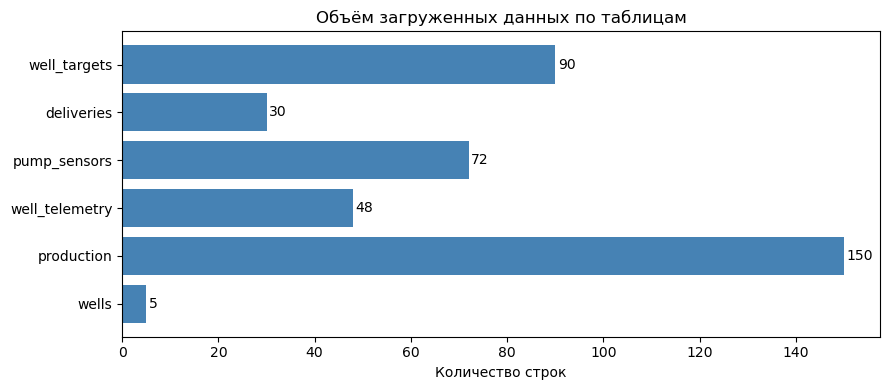


ETL pipeline завершён успешно!


In [9]:
import matplotlib.pyplot as plt

summary = {
    'wells':         len(df_wells),
    'production':    len(df_production),
    'well_telemetry':len(df_telemetry),
    'pump_sensors':  len(df_pump_sensors),
    'deliveries':    len(df_deliveries),
    'well_targets':  len(df_targets),
}

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(list(summary.keys()), list(summary.values()), color='steelblue')
ax.set_xlabel('Количество строк')
ax.set_title('Объём загруженных данных по таблицам')
for i, v in enumerate(summary.values()):
    ax.text(v + 0.5, i, str(v), va='center')
plt.tight_layout()
plt.show()

print('\nETL pipeline завершён успешно!')